# Problem: Adversarial Attacks

If you encounter the following error while running the notebook:

```text
Running cells with '.venv (Python 3.12.12)' requires the ipykernel package.
Install 'ipykernel' into the Python environment. 
```

Please run the following command in your terminal:
```bash
pip install -i https://mirror-pypi.runflare.com/simple ipykernel
```

## **<span style="color:orange">Importing Libraries, Declaring Constants, Setting Seed & DEVICE </span>**

Installation

In [1]:
%pip install -i https://mirror-pypi.runflare.com/simple torch torchvision matplotlib tqdm numpy

Looking in indexes: https://mirror-pypi.runflare.com/simple

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


To load the downloaded weights, you'll need the `pytorch_cifar_models` package. Please ensure that you place the downloaded `pytorch_cifar_models` folder (from elearn) in the same directory as your code.

Alternatively, you can clone the repository directly by running the following command in your terminal:
```bash
!git clone https://github.com/chenyaofo/pytorch-cifar-models.git


In [2]:
import sys

sys.path.append("pytorch-cifar-models")

import pytorch_cifar_models as pcm

Library

In [3]:
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

Set DEVICE

In [4]:
DEVICE = "cpu"
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"

print(f"Using device: {DEVICE}")

Using device: mps


Constants

In [5]:
BATCH_SIZE = 4

In [6]:
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [7]:
CIFAR10_DIR = "./HW1_Files/Q2/cifar10_correct_samples"
RESENET20_WEIGHTS = "./HW1_Files/Q2/cifar10_resnet20-4118986f.pt"

## **<span style="color:orange">Load Model & Data</span>**

Load model

In [8]:
model = pcm.cifar10_resnet20(pretrained=False)

In [9]:
state_dict = torch.load(RESENET20_WEIGHTS, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
model.to(DEVICE)

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Load image

In [10]:
class CIFARCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.files = [f for f in os.listdir(root_dir) if f.endswith(".png")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.root_dir, filename)

        # load image
        image = Image.open(path).convert("RGB")

        # parse label from filename: "..._true3.png"
        label_str = filename.split("_true")[1].split(".png")[0]
        label = int(label_str)

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean.flatten().tolist(), std=std.flatten().tolist()),
    ]
)

dataset = CIFARCustomDataset(root_dir=CIFAR10_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
print(f"Number of images: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Number of images: 25
Number of batches: 7


Check Model and Dataset Load

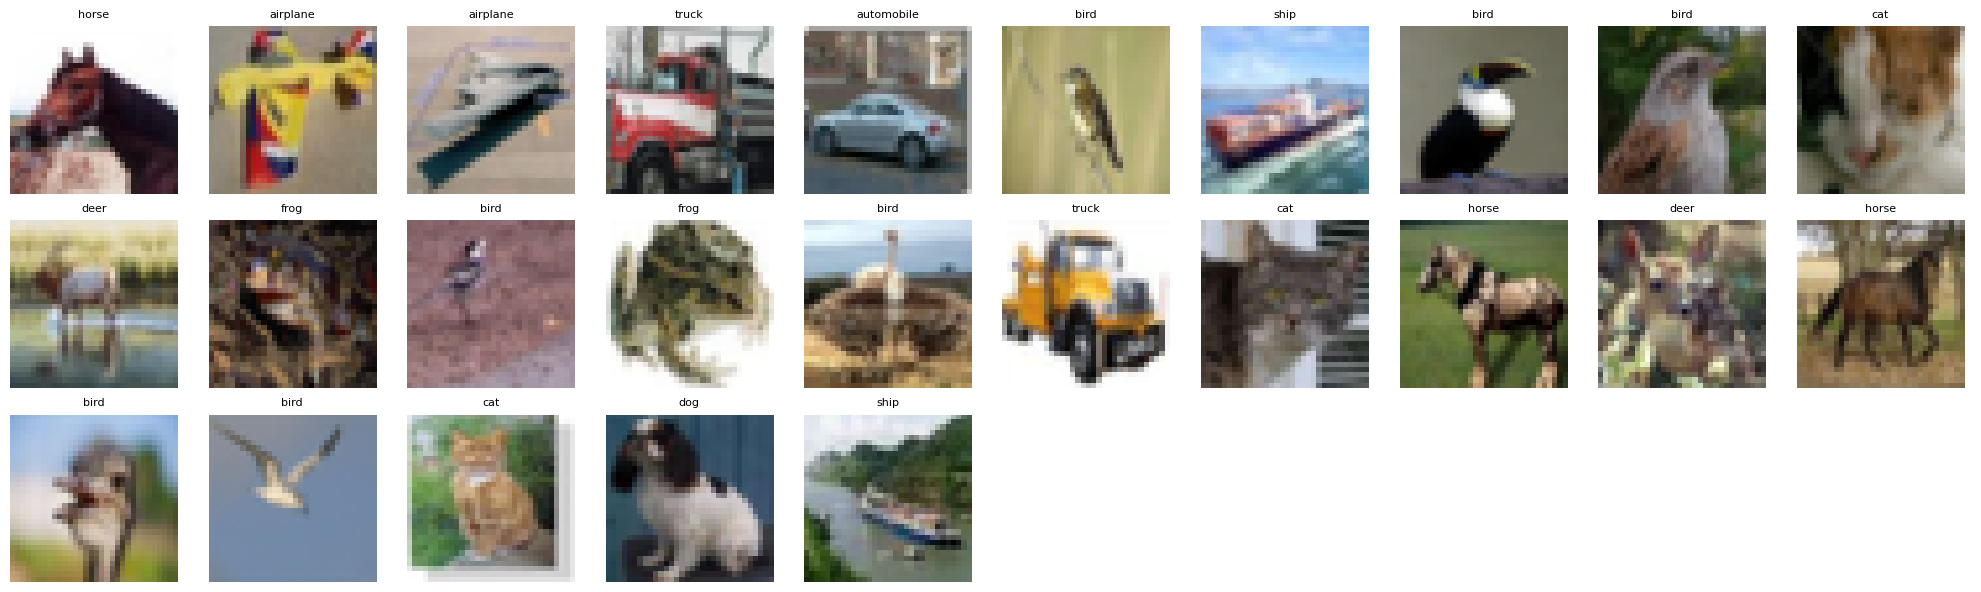

In [13]:
num_images = len(dataset)
cols = 10
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    img, true_lbl = dataset[i]
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{CIFAR10_CLASSES[true_lbl]}", fontsize=8)
    axes[i].axis("off")

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [14]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [15]:
accuracy_clean_data = evaluate(model, dataloader)
print(
    f"Accuracy of the model on the {len(dataset)} clean images: {accuracy_clean_data:.4f}"
)

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 16.53it/s]

Accuracy of the model on the 25 clean images: 1.0000


## **<span style="color:orange">Attacks</span>**

# Subsection 2

In [16]:
def predict( img):
    model.eval()
    if len(img.shape) == 3:
        img = img.unsqueeze(0)
    with torch.no_grad():
        img = img.to(DEVICE)
        outputs = model(img)
        _, predicted = torch.max(outputs.data, 1)
        return predicted.item()
def get_entry(ind):
    img, label = dataset[ind]
    img = img.clone()
    img = img * std + mean
    return img, label

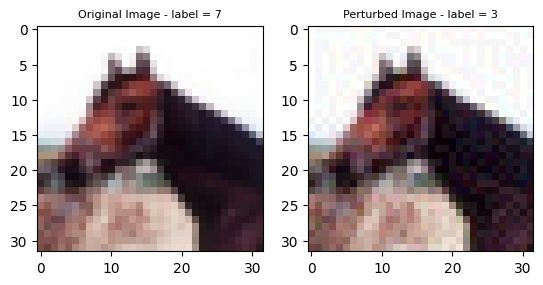

In [17]:
import torch
import torch.nn as nn

def fgsm_attack(ind,  epsilon=0.03):
    image, label = get_entry(ind)

    image=image.to(DEVICE).unsqueeze(0)
    label=torch.tensor([label]).to(DEVICE)

    image = image.requires_grad_(True)
    
    output = model(image)
    
    loss = nn.CrossEntropyLoss()(output, label)
    
    model.zero_grad()
    loss.backward()
    
    grad = image.grad.data

    delta = epsilon * grad.sign()
    
    perturbed_image = image + delta
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    
    return delta, perturbed_image



img, _ = get_entry(0)
_, perturbed_img = fgsm_attack(
    ind = 0,
    epsilon=0.03
)
plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title(f"Original Image - label = {predict(img)}", fontsize=8)

plt.subplot(1, 2, 2)
plt.imshow(perturbed_img.detach().cpu().squeeze().permute(1, 2, 0).numpy())
plt.title(f"Perturbed Image - label = {predict(perturbed_img)}", fontsize=8)
plt.show()


In [18]:
correct_predictions = 0
l2_distances = []
for i in range(num_images):
    img, true_lbl = dataset[i]

    delta, perturbed_img = fgsm_attack(
        ind = i,
        epsilon=0.03
    )
    l2_distances.append(np.linalg.norm(delta.detach().cpu().numpy().flatten(), ord=2))

    pred_perturbed = predict(perturbed_img)
    if pred_perturbed == true_lbl:
        correct_predictions += 1

accuracy_perturbed = correct_predictions / num_images
print(f"Accuracy of the model on the {num_images} perturbed images: {accuracy_perturbed:.2f}")
print(f"Average L2 distance of delta: {np.mean(l2_distances):.4f}")

Accuracy of the model on the 25 perturbed images: 0.08
Average L2 distance of delta: 1.6628


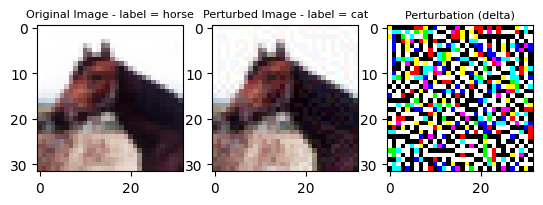

In [19]:
def plot(ind: int, attack_func, row = 0, total_rows = 1):
    img, true_lbl = get_entry(ind)

    delta, perturbed_img = attack_func(
        ind=ind,
    )

    pred_perturbed = predict( perturbed_img)

    plt.subplot(total_rows, 3, row * 3 + 1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"Original Image - label = {CIFAR10_CLASSES[true_lbl]}", fontsize=8)

    plt.subplot(total_rows, 3, row * 3 + 2)
    plt.imshow(perturbed_img.detach().cpu().squeeze().permute(1, 2, 0).numpy())
    plt.title(f"Perturbed Image - label = {CIFAR10_CLASSES[pred_perturbed]}", fontsize=8)

    plt.subplot(total_rows, 3, row * 3 + 3)
    delta = delta.detach().cpu().squeeze().permute(1, 2, 0).numpy()
    delta = (delta - (-0.03)) / (0.03 - (-0.03) )
    plt.imshow(delta)
    plt.title(f"Perturbation (delta)", fontsize=8)
plot(0, fgsm_attack)

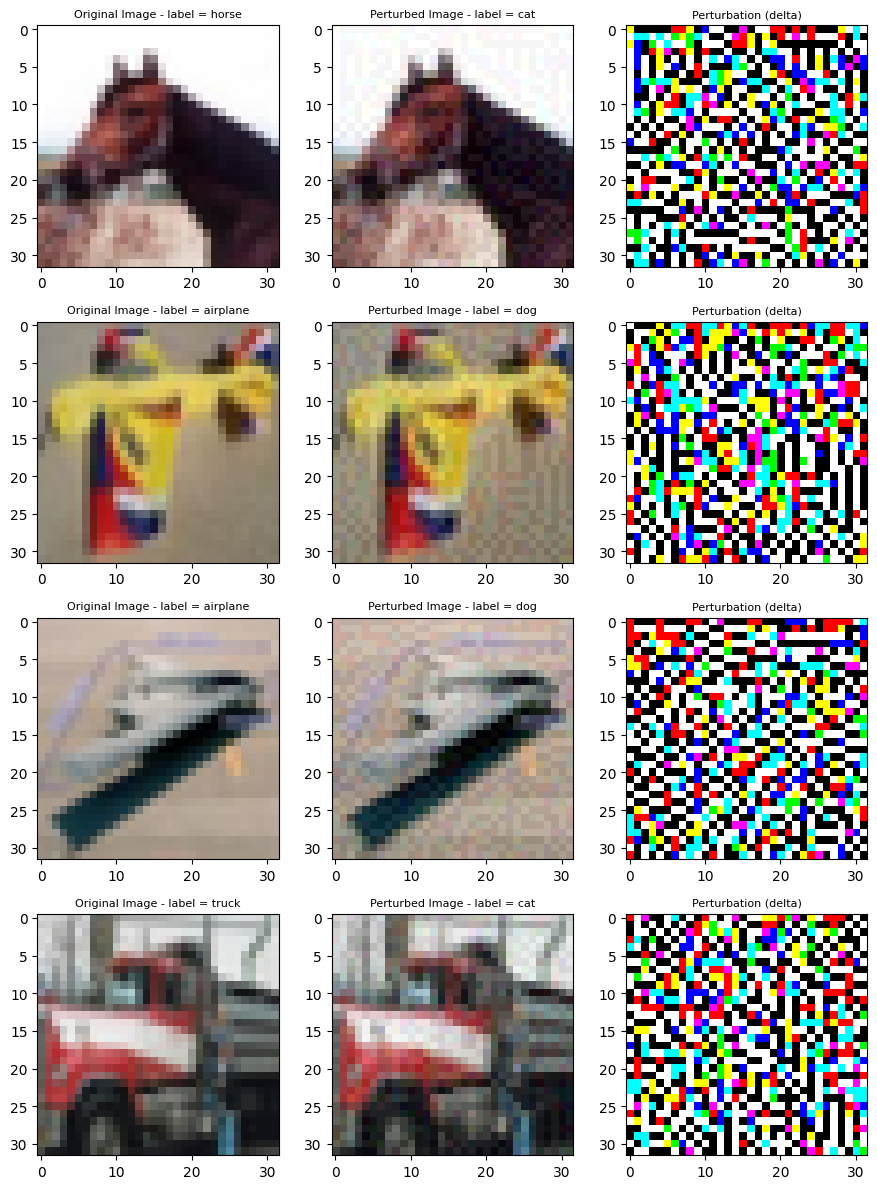

In [20]:
scale= 3
plt.figure(figsize=(3 * scale, 4* scale))
row = 0
for i in range(num_images):
    original_img, label = get_entry(i)
    _, perturbed_img = fgsm_attack(i)
    pred = predict(perturbed_img)
    if pred == label:
        continue

    plot(i, fgsm_attack, row=row, total_rows=4)
    row += 1
    if row == 4:
        break
plt.tight_layout()
plt.savefig("./report/images/q2_fgsm_examples.png")

# Subsection 3

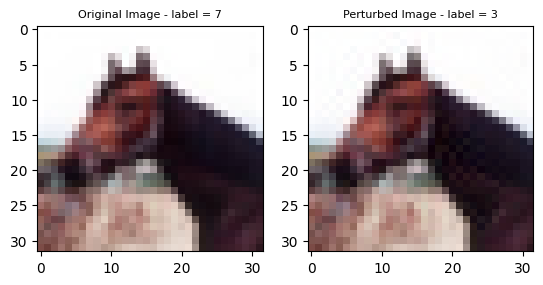

In [21]:
def pgd_attack(ind,  epsilon=0.03, alpha = 0.005, max_step: int = 20):
    image, label = get_entry(ind)

    image=image.to(DEVICE).unsqueeze(0)
    label=torch.tensor([label]).to(DEVICE)

    delta = torch.zeros_like(image).to(DEVICE)
    for _ in range(max_step):
        perturbed_image = image + delta
        perturbed_image = torch.clamp(perturbed_image, 0, 1)
        perturbed_image.requires_grad_(True)
        
        output = model(perturbed_image)
        
        loss = nn.CrossEntropyLoss()(output, label)
        
        model.zero_grad()
        loss.backward()
        
        grad = perturbed_image.grad.data

        delta += alpha * grad
        delta = torch.clamp(delta, -epsilon, epsilon)
        
    return delta, perturbed_image

img, _ = get_entry(0)
_, perturbed_img = pgd_attack(
    ind = 0,
)
plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title(f"Original Image - label = {predict(img)}", fontsize=8)

plt.subplot(1, 2, 2)
plt.imshow(perturbed_img.detach().cpu().squeeze().permute(1, 2, 0).numpy())
plt.title(f"Perturbed Image - label = {predict(perturbed_img)}", fontsize=8)
plt.show()

In [22]:
correct_predictions = 0
l2_distances = []
for i in range(num_images):
    img, true_lbl = dataset[i]

    delta, perturbed_img = pgd_attack(
        ind = i,
    )
    l2_distances.append(np.linalg.norm(delta.detach().cpu().numpy().flatten(), ord=2))

    pred_perturbed = predict(perturbed_img)
    if pred_perturbed == true_lbl:
        correct_predictions += 1

accuracy_perturbed = correct_predictions / num_images
print(f"Accuracy of the model on the {num_images} perturbed images: {accuracy_perturbed:.2f}")
print(f"Average L2 distance of delta: {np.mean(l2_distances):.4f}")

Accuracy of the model on the 25 perturbed images: 0.04
Average L2 distance of delta: 0.9128


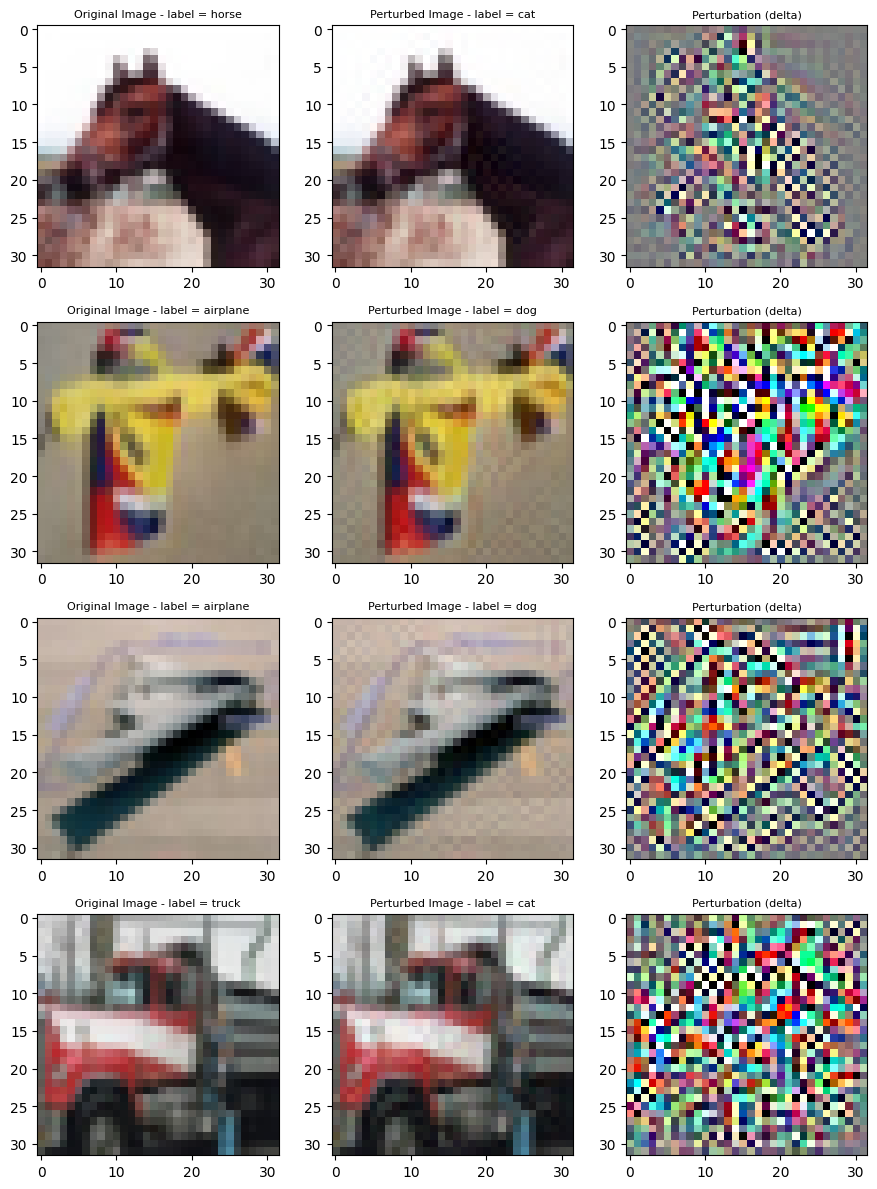

In [23]:

scale= 3
plt.figure(figsize=(3 * scale, 4* scale))
row = 0
for i in range(num_images):
    original_img, label = get_entry(i)
    _, perturbed_img = pgd_attack(i)
    pred = predict(perturbed_img)
    if pred == label:
        continue

    plot(i, pgd_attack, row=row, total_rows=4)
    row += 1
    if row == 4:
        break
plt.tight_layout()
plt.savefig("./report/images/q2_pgd_examples.png")